# 01. ACOS Setup, Pretrained Model Caching & Exploratory Data Analysis (EDA)

**Aspect-Category-Opinion-Sentiment (ACOS) Quadruple Extraction**

This notebook handles the initial setup for running ACOS on **Google Colab** (or Local environment), checks GPU acceleration, downloads and caches the pretrained `bert-base-uncased` model assets locally (to eliminate legacy S3 download failures), and performs comprehensive Exploratory Data Analysis (EDA) with publication-quality visualizations and CSV statistical exports.

## 1. Environment Setup & Dependency Installation
Install required dependencies (`torchcrf`, `transformers`, `huggingface_hub`, `seaborn`, `scikit-learn`).

In [97]:
# Check if running on Google Colab
try:
    import google.colab
    IN_COLAB = True
    print("🚀 Running in Google Colab environment.")
except ImportError:
    IN_COLAB = False
    print("💻 Running in Local environment.")

# Install dependencies
!pip install -q pytorch-crf transformers huggingface_hub seaborn scikit-learn matplotlib pandas boto3

import os
import sys
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Check GPU Availability
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"✅ GPU Detected: {torch.cuda.get_device_name(0)}")
    print(f"   Total VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    device = torch.device("cpu")
    print("⚠️ No GPU detected. Running on CPU.")

🚀 Running in Google Colab environment.
✅ GPU Detected: Tesla T4
   Total VRAM: 15.64 GB


## 2. Directory Navigation & Path Initialization

In [98]:
# 1. Detect if repository is present; if running in fresh Colab session, auto-clone repository
if not os.path.exists("Extract-Classify-ACOS") and not os.path.exists("../Extract-Classify-ACOS"):
    if not os.path.exists("ACOS"):
        print("📥 Cloning ACOS repository from GitHub into Colab environment...")
        !git clone https://github.com/haisyamalawwab/ACOS.git

# 2. Robustly locate base project directory across Colab & Local
if os.path.exists("Extract-Classify-ACOS"):
    base_project_dir = os.path.abspath(".")
elif os.path.exists("../Extract-Classify-ACOS"):
    base_project_dir = os.path.abspath("..")
elif os.path.exists("ACOS/Extract-Classify-ACOS"):
    base_project_dir = os.path.abspath("ACOS")
elif os.path.exists("/content/ACOS/Extract-Classify-ACOS"):
    base_project_dir = "/content/ACOS"
elif os.path.exists("/content/Extract-Classify-ACOS"):
    base_project_dir = "/content"
else:
    base_project_dir = os.path.abspath(".")

extract_dir = os.path.join(base_project_dir, "Extract-Classify-ACOS")
notebooks_dir = os.path.join(base_project_dir, "notebooks")

for p in [base_project_dir, extract_dir, notebooks_dir]:
    if p not in sys.path:
        sys.path.insert(0, p)

# 3. Import colab_utils with fallback download
try:
    from colab_utils import (
        setup_timestamped_run_dir, download_bert_pretrained, analyze_and_plot_eda,
        plot_training_history, export_benchmark_tables_and_plots,
        display_quadruple_dataframe, df_to_markdown, export_step_table,
        MarkdownReport, SubtaskMetricCapture, plot_subtask_metrics,
        features_step1, features_step2, pair_examples_from_file,
        resolve_eval_pair_file, unpack_model_output,
    )
except ModuleNotFoundError:
    import urllib.request
    print("⚠️ Downloading colab_utils.py fallback directly from GitHub...")
    raw_url = "https://raw.githubusercontent.com/haisyamalawwab/ACOS/main/notebooks/colab_utils.py"
    urllib.request.urlretrieve(raw_url, "colab_utils.py")
    from colab_utils import (
        setup_timestamped_run_dir, download_bert_pretrained, analyze_and_plot_eda,
        plot_training_history, export_benchmark_tables_and_plots,
        display_quadruple_dataframe, df_to_markdown, export_step_table,
        MarkdownReport, SubtaskMetricCapture, plot_subtask_metrics,
        features_step1, features_step2, pair_examples_from_file,
        resolve_eval_pair_file, unpack_model_output,
    )

print(f"📂 Base project directory: {base_project_dir}")
print(f"📁 Extract & Model directory: {extract_dir}")


📥 Cloning ACOS repository from GitHub into Colab environment...
Cloning into 'ACOS'...
remote: Enumerating objects: 956, done.
remote: Counting objects: 100% (115/115), done.
remote: Compressing objects: 100% (71/71), done.
remote: Total 956 (delta 74), reused 55 (delta 44), pack-reused 841 (from 2)
Receiving objects: 100% (956/956), 8.10 MiB | 13.37 MiB/s, done.
Resolving deltas: 100% (519/519), done.
📂 Base project directory: /content/ACOS
📁 Extract & Model directory: /content/ACOS/Extract-Classify-ACOS


## 3. Initialize Timestamped Session Directory (`DDMMYYYY_HMS`)
Every session automatically creates an isolated directory inside `results/` for storing plots, CSV tables, model checkpoints, and execution logs.

In [99]:
# Choose domain: 'rest16' (Restaurant-ACOS) or 'laptop' (Laptop-ACOS)
DOMAIN = "rest16"

results_base = os.path.join(base_project_dir, "results")
session_dirs = setup_timestamped_run_dir(base_dir=results_base, domain=DOMAIN)

print("Directory structure:")
for k, v in session_dirs.items():
    print(f"  - {k}: {v}")
# Direktori Markdown untuk hasil teks tiap step
md_dir = session_dirs["md"]
plots_dir = session_dirs["plots"]
csv_dir = session_dirs["csv"]
logs_dir = session_dirs["logs"]

# Akumulator laporan Markdown untuk notebook ini
rep = MarkdownReport(
    f"01 - Setup & EDA [{DOMAIN.upper()}]",
    md_dir,
    filename="01_setup_dan_eda.md",
    meta={"domain": DOMAIN, "session_dir": session_dirs["root"], "device": str(device)},
)
print(f"[md] Hasil teks notebook ini akan ditulis ke: {md_dir}")


📁 Initialized timestamped session directory: /content/ACOS/results/rest16_29082026_144216
Directory structure:
  - root: /content/ACOS/results/rest16_29082026_144216
  - checkpoints: /content/ACOS/results/rest16_29082026_144216/checkpoints
  - step1_checkpoint: /content/ACOS/results/rest16_29082026_144216/checkpoints/step1_best
  - step2_checkpoint: /content/ACOS/results/rest16_29082026_144216/checkpoints/step2_best
  - plots: /content/ACOS/results/rest16_29082026_144216/plots
  - csv: /content/ACOS/results/rest16_29082026_144216/csv
  - md: /content/ACOS/results/rest16_29082026_144216/md
  - logs: /content/ACOS/results/rest16_29082026_144216/logs
[md] Hasil teks notebook ini akan ditulis ke: /content/ACOS/results/rest16_29082026_144216/md


## 4. Download & Cache Pretrained BERT Model (`bert-base-uncased`)
Downloads `config.json`, `pytorch_model.bin`, and `vocab.txt` directly from HuggingFace Hub to local cache `./bert_base_uncased`.

In [100]:
bert_cache_dir = os.path.join(base_project_dir, "bert_base_uncased")
download_bert_pretrained(target_dir=bert_cache_dir)

# Verify files
for f in ["config.json", "pytorch_model.bin", "vocab.txt"]:
    fpath = os.path.join(bert_cache_dir, f)
    assert os.path.exists(fpath), f"Missing BERT file: {fpath}"
    print(f"✅ {f} ({os.path.getsize(fpath)/1024/1024:.2f} MB)")

📥 Downloading config.json to /content/ACOS/bert_base_uncased/config.json ...
📥 Downloading pytorch_model.bin to /content/ACOS/bert_base_uncased/pytorch_model.bin ...
📥 Downloading vocab.txt to /content/ACOS/bert_base_uncased/vocab.txt ...
✅ config.json (0.00 MB)
✅ pytorch_model.bin (420.07 MB)
✅ vocab.txt (0.22 MB)


## 5. Exploratory Data Analysis (EDA) & Visualization
Perform deep statistical analysis on `Restaurant-ACOS` (`rest16`) and `Laptop-ACOS` (`laptop`) datasets:
- Sentence and Quadruple counts per split (Train / Dev / Test)
- Explicit vs. Implicit Aspect and Opinion proportions
- Top Aspect Categories & Sentiment Polarity distributions
- Automatic export to high-resolution PNG plots (`plots/`) and CSV files (`csv/`).

In [101]:
data_root = os.path.join(base_project_dir, "data")

df_stats, df_records = analyze_and_plot_eda(
    data_dir=data_root,
    domain=DOMAIN,
    output_plots_dir=plots_dir,
    output_csv_dir=csv_dir,
)

rep.section("1. Statistik dataset per split")

if df_stats is None or df_stats.empty:
    print("[peringatan] Statistik EDA kosong: cek keberadaan folder data/.")
    rep.text("Statistik EDA kosong. Folder `data/` tidak ditemukan atau kosong.")
else:
    export_step_table(
        df_stats,
        name="eda_01_statistik_per_split",
        csv_dir=csv_dir,
        md_dir=md_dir,
        title=f"Statistik Dataset {DOMAIN.upper()} per Split",
        notes="Kolom sentimen: 0 = negative, 1 = neutral, 2 = positive.",
    )
    rep.table(df_stats, caption="Statistik dasar per split")


📊 Saved EDA Statistics CSV: /content/ACOS/results/rest16_29082026_144216/csv/eda_dataset_statistics.csv


/content/drive/MyDrive/ACOS/_acos_utils/colab_utils.py:588: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_cats.index, x=top_cats.values, ax=axes[0], palette="viridis")


=== Statistik Dataset REST16 per Split (3 baris) ===


,Domain,Split,Sentences,Total_Quadruples,Explicit_Aspects,Implicit_Aspects,Explicit_Opinions,Implicit_Opinions,Negative_Count (0),Neutral_Count (1),Positive_Count (2)
0,rest16,train,1530,2484,1877,607,2036,448,733,95,1656
1,rest16,dev,171,261,201,60,207,54,69,12,180
2,rest16,test,583,916,703,213,718,198,205,44,667


[tabel] CSV: /content/ACOS/results/rest16_29082026_144216/csv/eda_01_statistik_per_split.csv | MD: /content/ACOS/results/rest16_29082026_144216/md/eda_01_statistik_per_split.md


### Sample Data Preview with Implicit/Explicit Flags

In [102]:
if df_records is None or df_records.empty:
    print("[peringatan] Tidak ada record quadruple untuk dianalisis.")
else:
    print(f"Total record quadruple: {len(df_records):,}")

    # 1. Preview sampel beranotasi
    export_step_table(
        df_records.head(25),
        name="eda_02_preview_sampel",
        csv_dir=csv_dir,
        md_dir=md_dir,
        title=f"Preview 25 Quadruple Beranotasi ({DOMAIN.upper()})",
        max_rows_md=25,
    )

    # 2. Rekap implicit vs explicit
    n = len(df_records)
    imp_rows = []
    for label, col in [("Implicit Aspect", "Is_Implicit_Aspect"),
                       ("Implicit Opinion", "Is_Implicit_Opinion")]:
        cnt = int(df_records[col].sum())
        imp_rows.append({"Tipe": label, "Jumlah": cnt,
                         "Persen": round(cnt / n * 100, 2),
                         "Total_Quadruple": n})
    both = int((df_records["Is_Implicit_Aspect"] & df_records["Is_Implicit_Opinion"]).sum())
    imp_rows.append({"Tipe": "Implicit Aspect + Implicit Opinion", "Jumlah": both,
                     "Persen": round(both / n * 100, 2), "Total_Quadruple": n})
    df_imp = pd.DataFrame(imp_rows)

    rep.section("2. Proporsi implicit vs explicit")
    export_step_table(
        df_imp, name="eda_03_rekap_implicit", csv_dir=csv_dir, md_dir=md_dir,
        title=f"Rekap Implicit Aspect/Opinion ({DOMAIN.upper()})",
    )
    rep.table(df_imp, caption="Proporsi implicit")

    # 3. Distribusi kategori lengkap
    df_cat = (df_records["Category"].value_counts()
              .rename_axis("Category").reset_index(name="Jumlah"))
    df_cat["Persen"] = (df_cat["Jumlah"] / n * 100).round(2)

    rep.section("3. Distribusi kategori aspek")
    export_step_table(
        df_cat, name="eda_04_distribusi_kategori", csv_dir=csv_dir, md_dir=md_dir,
        title=f"Distribusi Kategori Aspek ({DOMAIN.upper()}) - {len(df_cat)} kategori",
        max_rows_md=25,
    )
    rep.table(df_cat.head(15), caption="15 kategori terbanyak")

    # 4. Distribusi sentimen
    senti_names = {0: "negative (0)", 1: "neutral (1)", 2: "positive (2)"}
    df_senti = (df_records["Sentiment"].map(senti_names).value_counts()
                .rename_axis("Sentimen").reset_index(name="Jumlah"))
    df_senti["Persen"] = (df_senti["Jumlah"] / n * 100).round(2)

    rep.section("4. Distribusi polaritas sentimen")
    export_step_table(
        df_senti, name="eda_05_distribusi_sentimen", csv_dir=csv_dir, md_dir=md_dir,
        title=f"Distribusi Sentimen ({DOMAIN.upper()})",
    )
    rep.table(df_senti, caption="Polaritas sentimen")

    # 5. Statistik panjang kalimat
    df_len = df_records["Text_Length"].describe().to_frame("Nilai").reset_index()
    df_len.columns = ["Statistik", "Nilai"]

    rep.section("5. Statistik panjang kalimat")
    export_step_table(
        df_len, name="eda_06_statistik_panjang", csv_dir=csv_dir, md_dir=md_dir,
        title=f"Statistik Panjang Kalimat dalam Kata ({DOMAIN.upper()})",
    )
    rep.table(df_len, caption="Panjang kalimat (kata)")


Total record quadruple: 3,661
=== Preview 25 Quadruple Beranotasi (REST16) (25 baris) ===


,Domain,Split,Text,Aspect,Category,Sentiment,Opinion,Is_Implicit_Aspect,Is_Implicit_Opinion,Text_Length
0,rest16,train,judging from previous posts this used to be a ...,"10,11",RESTAURANT#GENERAL,0,"13,16",False,False,17
1,rest16,train,"we , there were four of us , arrived at noon -...","19,20",SERVICE#GENERAL,0,"31,32",False,False,33
2,rest16,train,"they never brought us complimentary noodles , ...","-1,-1",SERVICE#GENERAL,0,"-1,-1",True,True,21
3,rest16,train,the food was lousy - too sweet or too salty an...,"1,2",FOOD#QUALITY,0,"3,4",False,False,15
4,rest16,train,the food was lousy - too sweet or too salty an...,"1,2",FOOD#QUALITY,0,"5,7",False,False,15
5,rest16,train,the food was lousy - too sweet or too salty an...,"1,2",FOOD#QUALITY,0,"8,10",False,False,15
6,rest16,train,the food was lousy - too sweet or too salty an...,"12,13",FOOD#STYLE_OPTIONS,0,"13,14",False,False,15
7,rest16,train,"after all that , they complained to me about t...","-1,-1",SERVICE#GENERAL,0,"5,6",True,False,13
8,rest16,train,avoid this place !,"2,3",RESTAURANT#GENERAL,0,"0,1",False,False,4
9,rest16,train,"i have eaten at saul , many times , the food i...","10,11",FOOD#QUALITY,2,"15,17",False,False,18


[tabel] CSV: /content/ACOS/results/rest16_29082026_144216/csv/eda_02_preview_sampel.csv | MD: /content/ACOS/results/rest16_29082026_144216/md/eda_02_preview_sampel.md
=== Rekap Implicit Aspect/Opinion (REST16) (3 baris) ===


,Tipe,Jumlah,Persen,Total_Quadruple
0,Implicit Aspect,880,24.04,3661
1,Implicit Opinion,700,19.12,3661
2,Implicit Aspect + Implicit Opinion,350,9.56,3661


[tabel] CSV: /content/ACOS/results/rest16_29082026_144216/csv/eda_03_rekap_implicit.csv | MD: /content/ACOS/results/rest16_29082026_144216/md/eda_03_rekap_implicit.md
=== Distribusi Kategori Aspek (REST16) - 13 kategori (13 baris) ===


...

[tabel] CSV: /content/ACOS/results/rest16_29082026_144216/csv/eda_04_distribusi_kategori.csv | MD: /content/ACOS/results/rest16_29082026_144216/md/eda_04_distribusi_kategori.md
=== Distribusi Sentimen (REST16) (3 baris) ===


,Sentimen,Jumlah,Persen
0,positive (2),2503,68.37
1,negative (0),1007,27.51
2,neutral (1),151,4.12


[tabel] CSV: /content/ACOS/results/rest16_29082026_144216/csv/eda_05_distribusi_sentimen.csv | MD: /content/ACOS/results/rest16_29082026_144216/md/eda_05_distribusi_sentimen.md
=== Statistik Panjang Kalimat dalam Kata (REST16) (8 baris) ===


,Statistik,Nilai
0,count,3661.000000
1,mean,17.357279
2,std,11.707229
3,min,1.000000
4,25%,10.000000
5,50%,15.000000
6,75%,22.000000
7,max,84.000000


[tabel] CSV: /content/ACOS/results/rest16_29082026_144216/csv/eda_06_statistik_panjang.csv | MD: /content/ACOS/results/rest16_29082026_144216/md/eda_06_statistik_panjang.md


### Display Generated Visualization Charts
Visualizations are rendered inline and saved to `plots/`.

[plot] Komposisi dataset & explicit vs implicit aspect


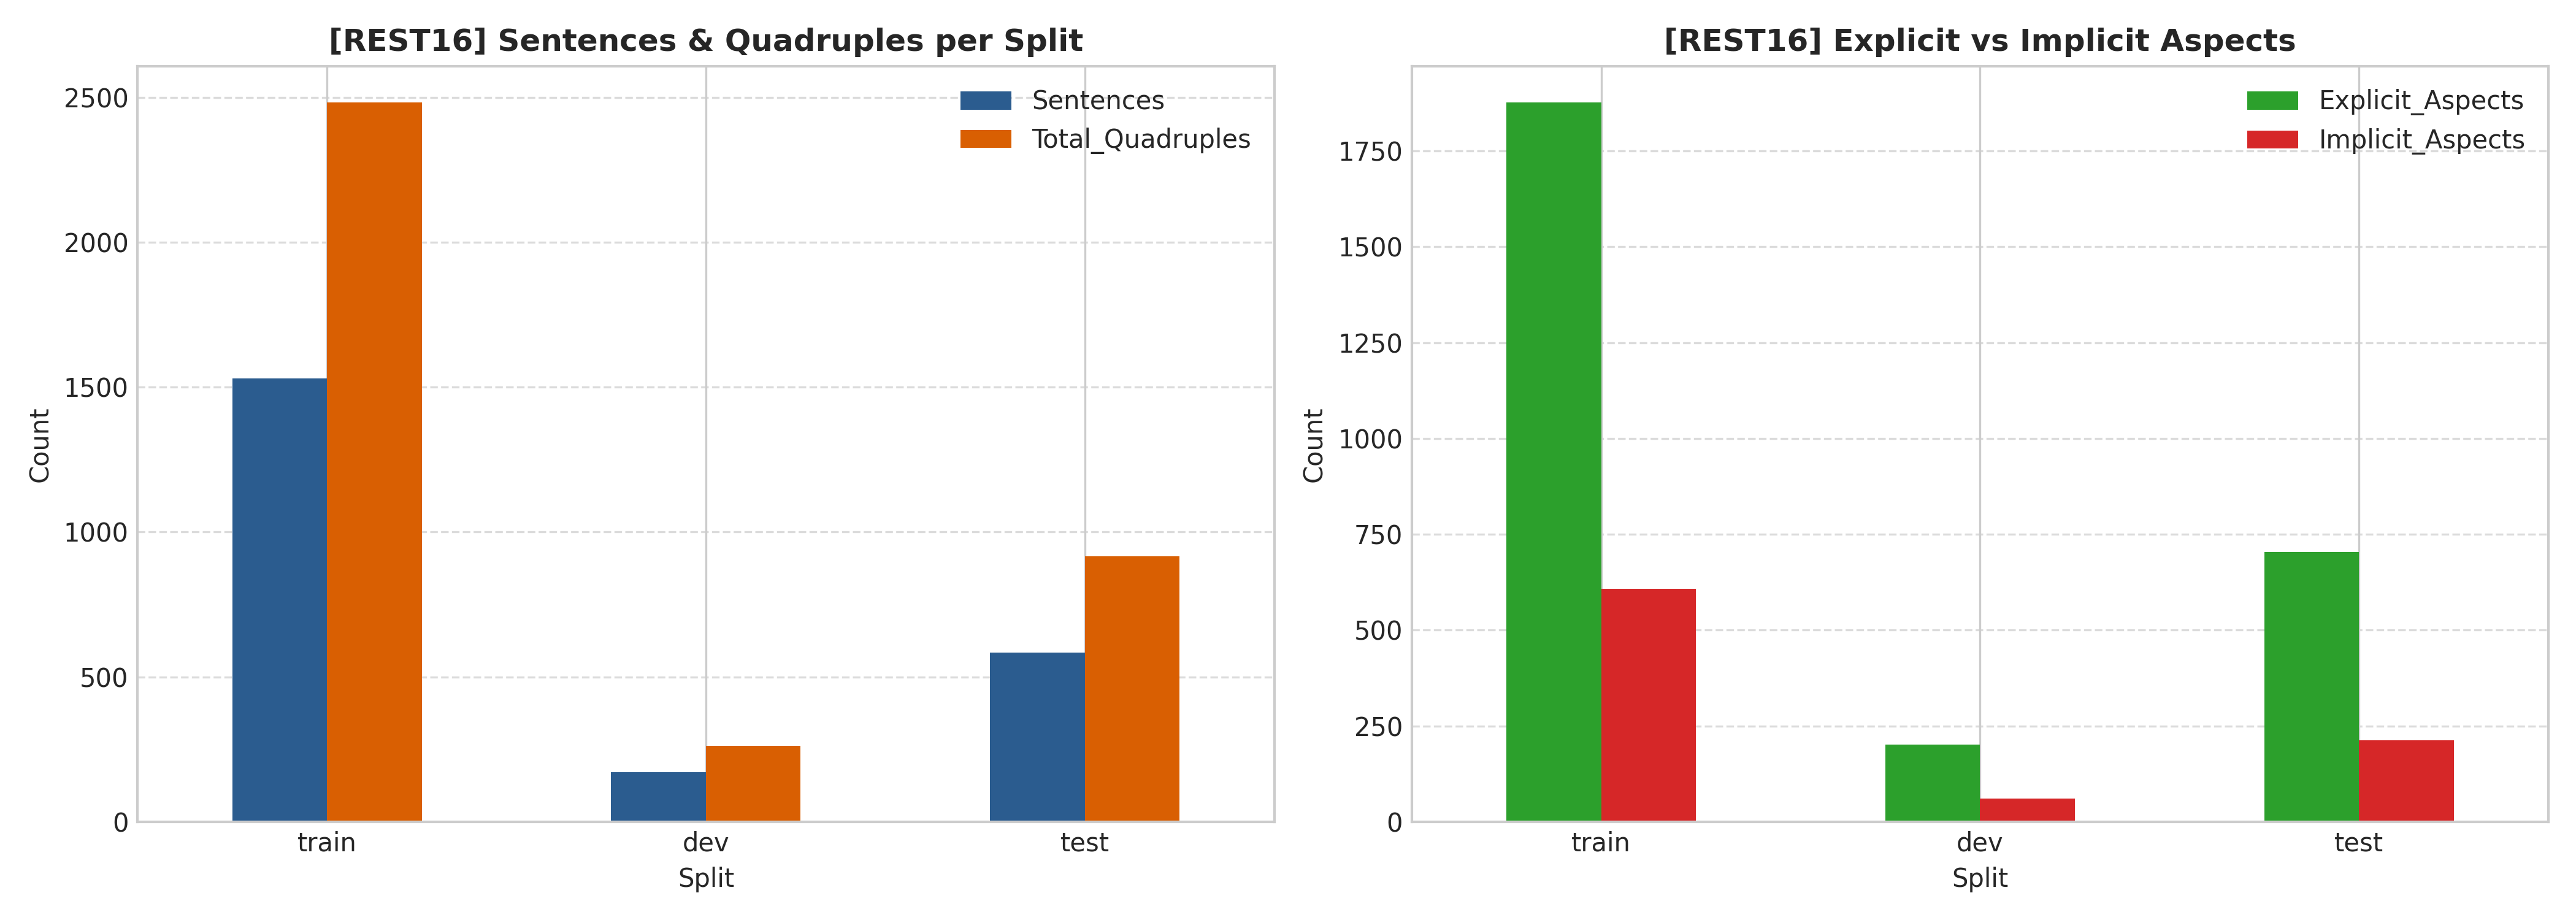

[plot] Kategori teratas & breakdown polaritas sentimen


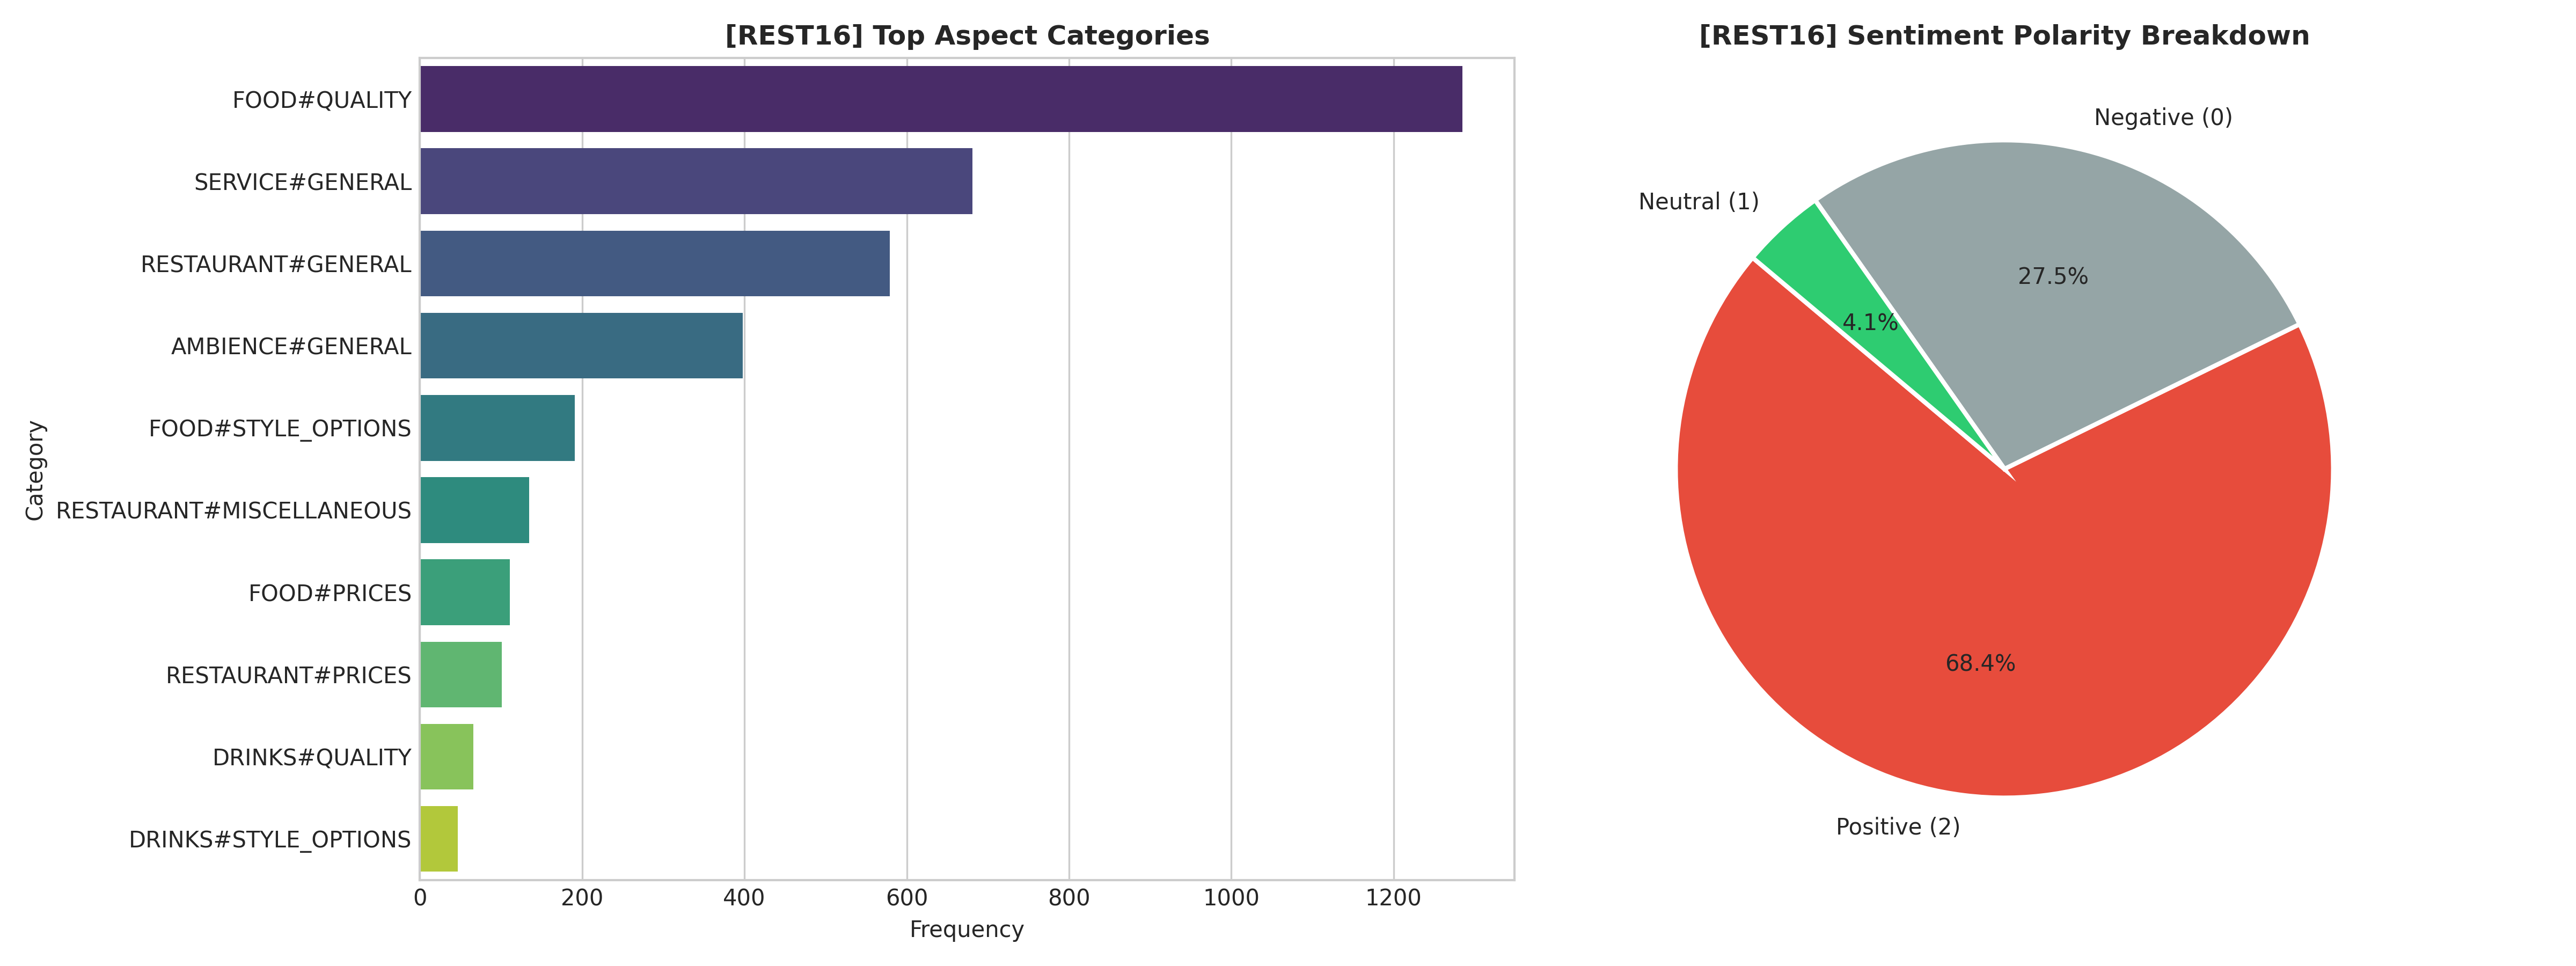

[plot] Distribusi panjang kalimat & kombinasi implicit/explicit


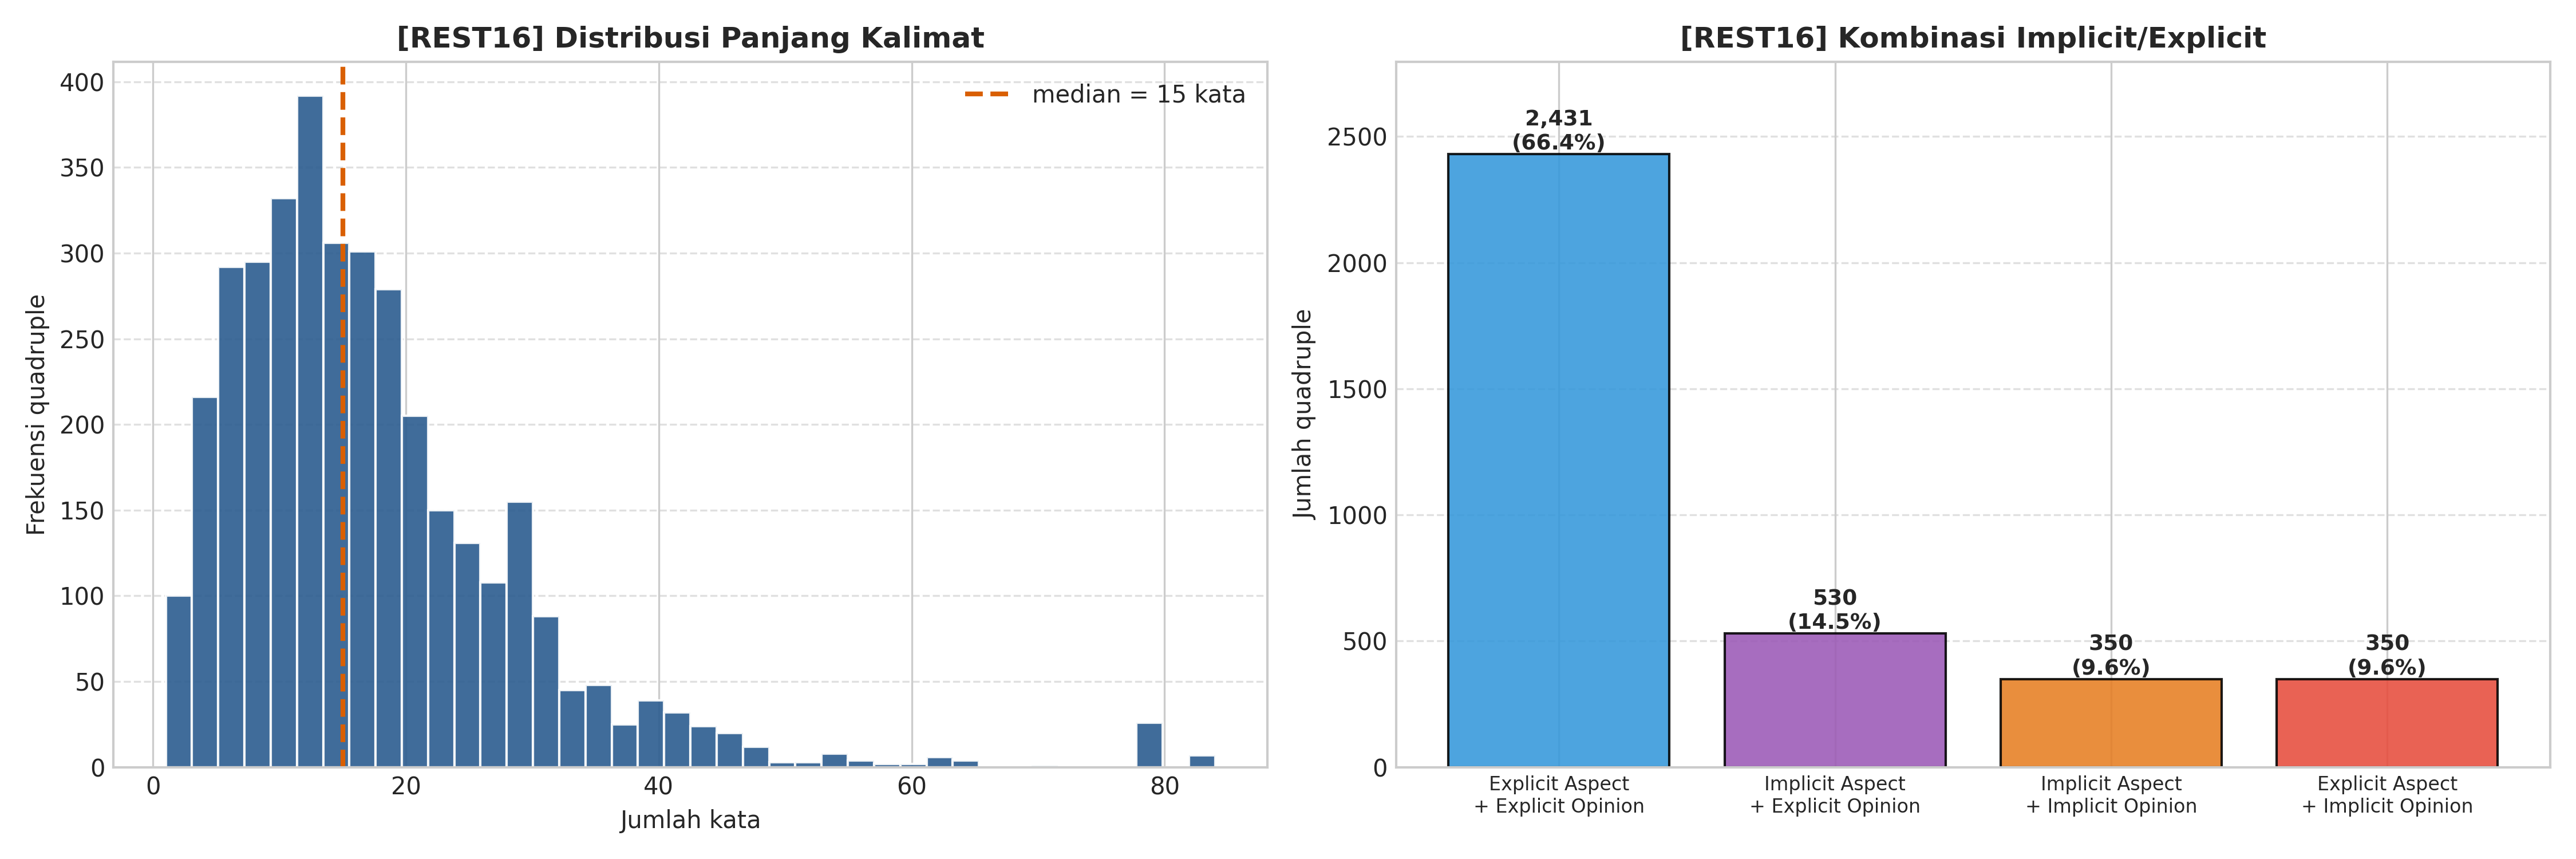

[plot] Heatmap kategori (top 12) x sentimen


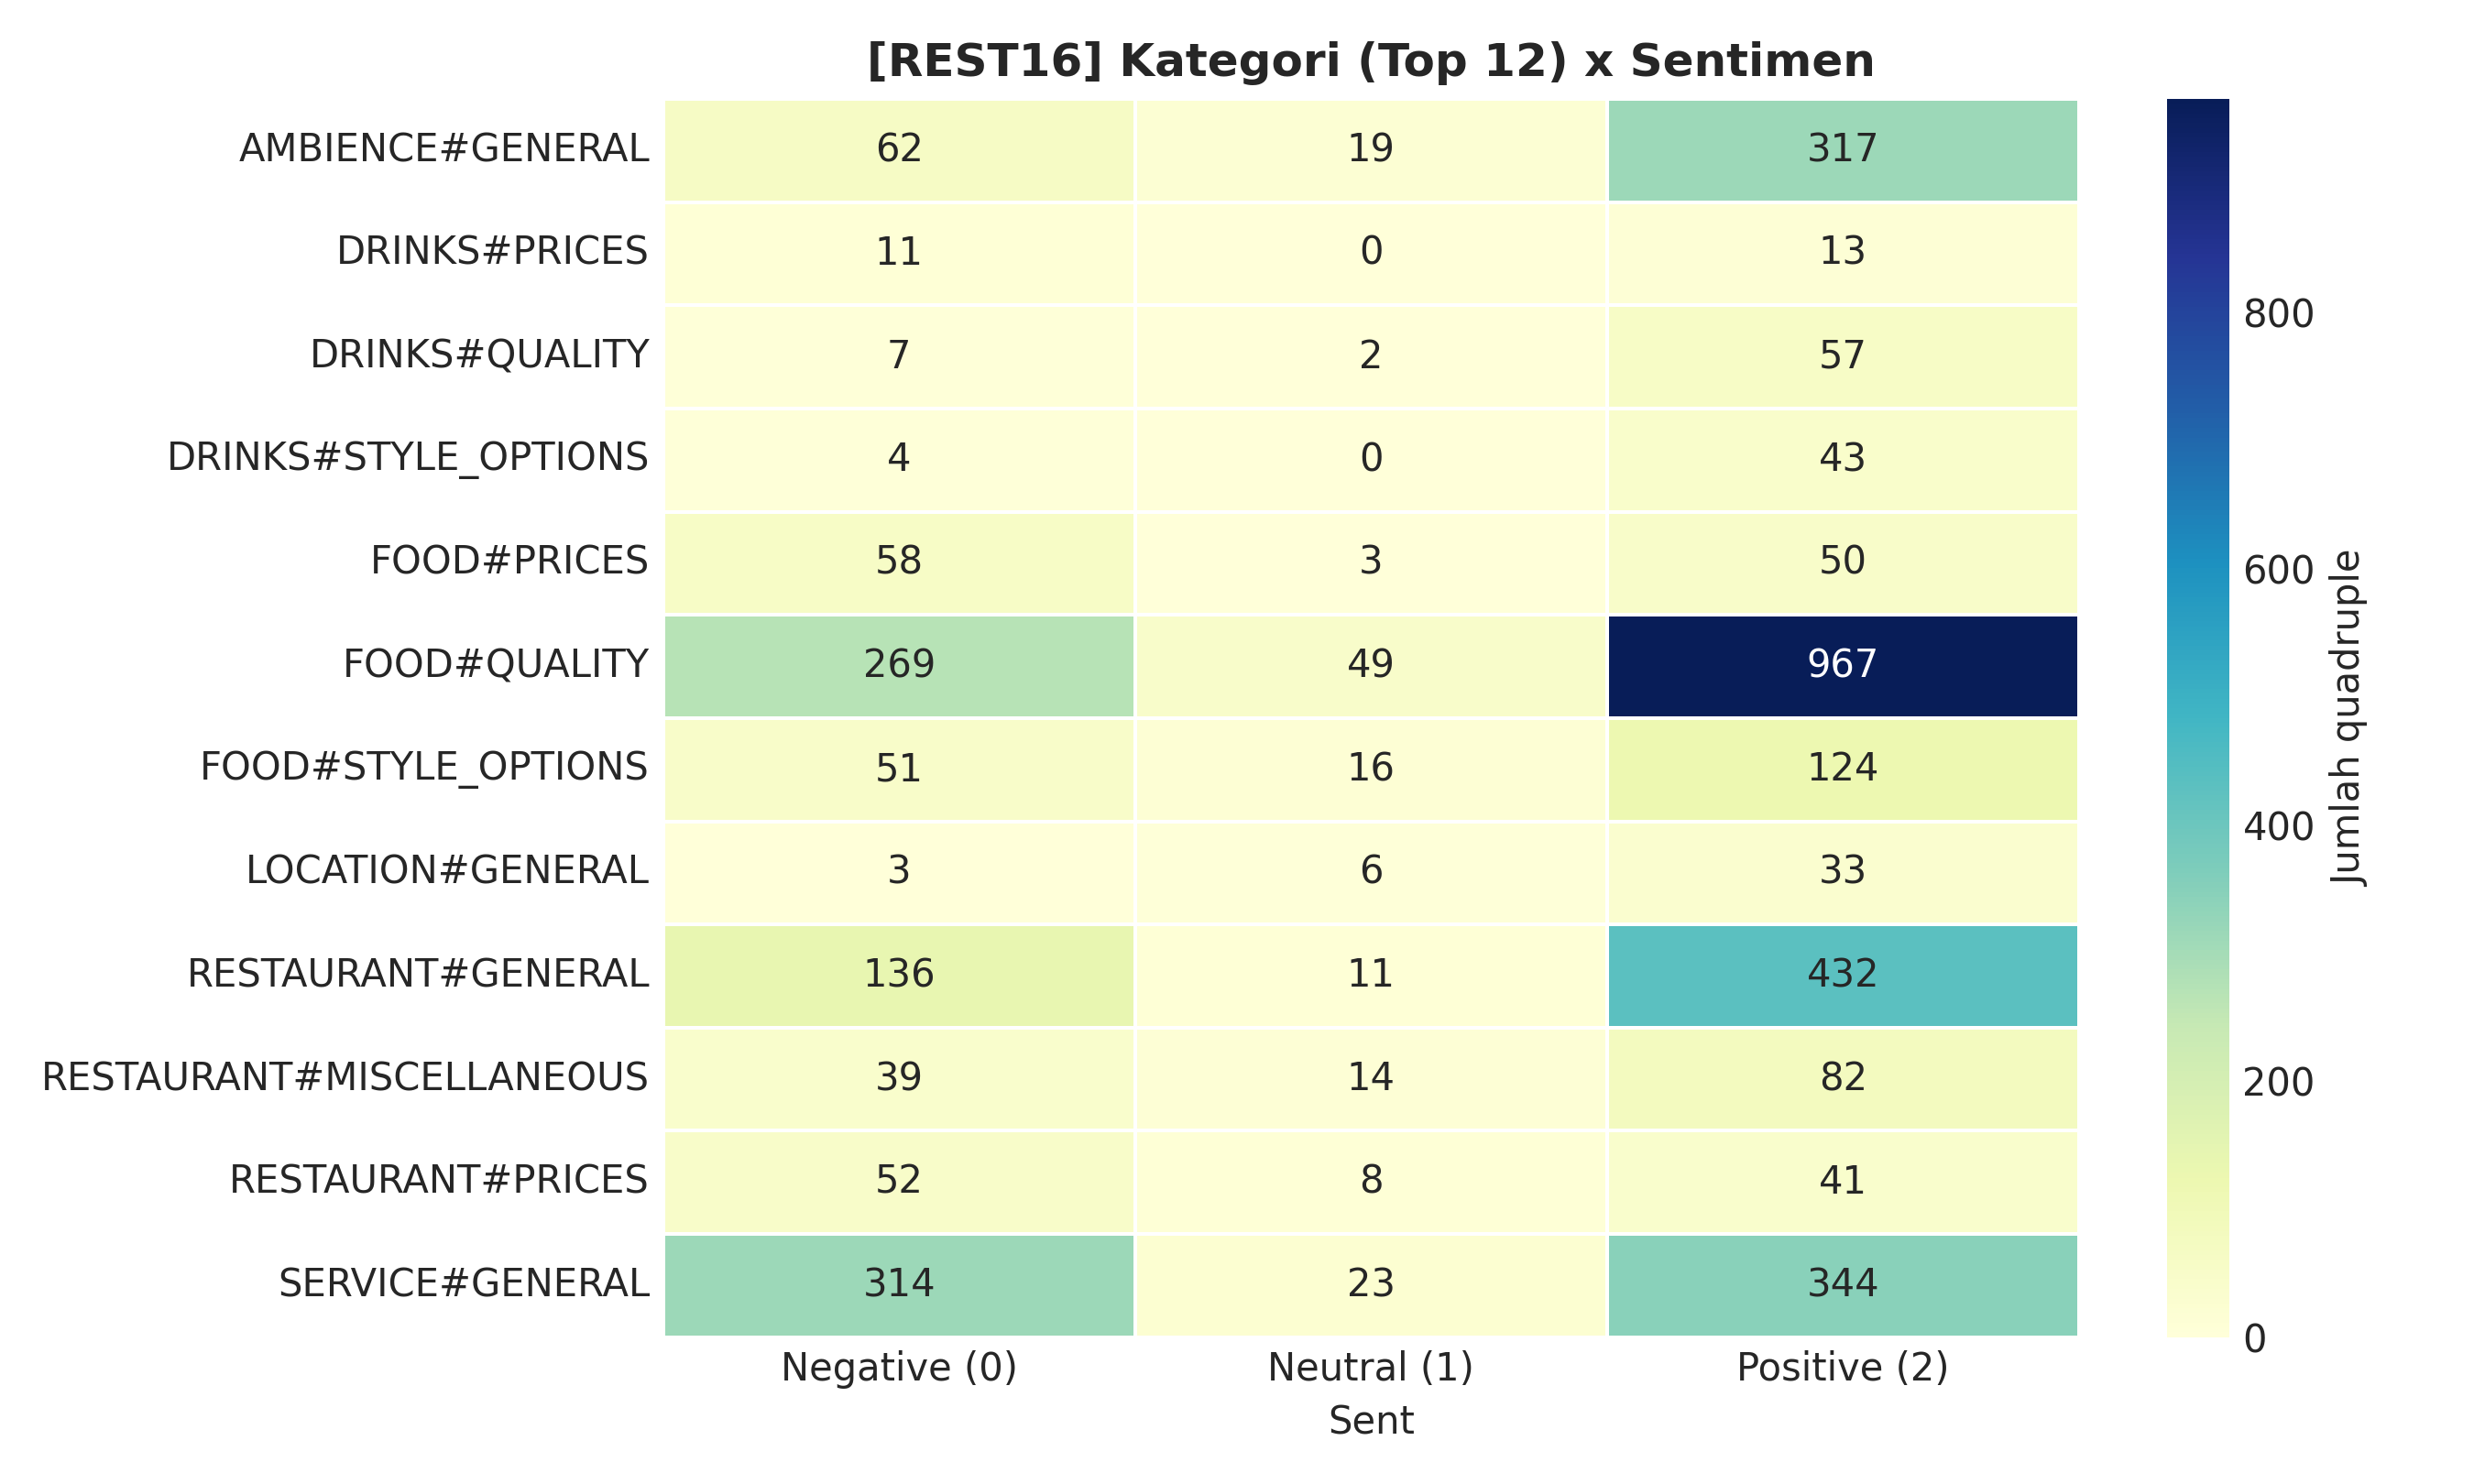


4/4 plot ditampilkan.


In [103]:
from IPython.display import Image, display

eda_plots = [
    ("01_eda_dataset_distribution.png", "Komposisi dataset & explicit vs implicit aspect"),
    ("02_eda_category_sentiment.png", "Kategori teratas & breakdown polaritas sentimen"),
    ("02b_eda_length_and_implicit_combo.png", "Distribusi panjang kalimat & kombinasi implicit/explicit"),
    ("02c_eda_category_sentiment_heatmap.png", "Heatmap kategori (top 12) x sentimen"),
]

rep.section("6. Visualisasi")
shown = 0
for fname, caption in eda_plots:
    path = os.path.join(plots_dir, fname)
    if os.path.exists(path):
        print(f"[plot] {caption}")
        display(Image(path))
        rep.image(path, caption)
        shown += 1
    else:
        print(f"[plot] Tidak ditemukan (dilewati): {fname}")

print(f"\n{shown}/{len(eda_plots)} plot ditampilkan.")


## 6. Summary of Exported Artifacts
All outputs from this step are safely persisted in the timestamped session directory:

In [104]:
def _list_dir(label, path):
    rows = []
    if os.path.isdir(path):
        for f in sorted(os.listdir(path)):
            fp = os.path.join(path, f)
            if os.path.isfile(fp):
                rows.append({"Jenis": label, "Nama": f,
                             "Ukuran_KB": round(os.path.getsize(fp) / 1024, 1)})
    return rows

artefak = (_list_dir("CSV", csv_dir) + _list_dir("Plot", plots_dir)
           + _list_dir("Markdown", md_dir) + _list_dir("Log", logs_dir))
df_art = pd.DataFrame(artefak)

rep.section("7. Artefak yang dihasilkan")
if not df_art.empty:
    export_step_table(
        df_art, name="eda_07_daftar_artefak", csv_dir=csv_dir, md_dir=md_dir,
        title="Daftar Artefak Sesi EDA", max_rows_md=100,
    )
    rep.table(df_art, max_rows=100, caption="Artefak sesi")

rep.text(f"Sesi: `{session_dirs['root']}`")
report_path = rep.save()

print(f"\nLaporan Markdown notebook 01: {report_path}")
print("Lanjut ke '02_ACOS_Step1_Aspect_Opinion_Extraction.ipynb'.")


=== Daftar Artefak Sesi EDA (18 baris) ===


,Jenis,Nama,Ukuran_KB
0,CSV,eda_01_statistik_per_split.csv,0.3
1,CSV,eda_02_preview_sampel.csv,3.4
2,CSV,eda_03_rekap_implicit.csv,0.1
3,CSV,eda_04_distribusi_kategori.csv,0.3
4,CSV,eda_05_distribusi_sentimen.csv,0.1
5,CSV,eda_06_statistik_panjang.csv,0.1
6,CSV,eda_all_samples_annotated.csv,510.0
7,CSV,eda_dataset_statistics.csv,0.3
8,Plot,01_eda_dataset_distribution.png,139.2
9,Plot,02_eda_category_sentiment.png,275.6


[tabel] CSV: /content/ACOS/results/rest16_29082026_144216/csv/eda_07_daftar_artefak.csv | MD: /content/ACOS/results/rest16_29082026_144216/md/eda_07_daftar_artefak.md
[markdown] Laporan disimpan: /content/ACOS/results/rest16_29082026_144216/md/01_setup_dan_eda.md

Laporan Markdown notebook 01: /content/ACOS/results/rest16_29082026_144216/md/01_setup_dan_eda.md
Lanjut ke '02_ACOS_Step1_Aspect_Opinion_Extraction.ipynb'.
